# Mechanics of Composites: AERO 331 (Winter 2026)

*Intructor:* Dr. Amuthan Ramabathiran  
*Email:* aramabat@calpoly.edu  

## About this notebook

This notebook will help you explore different layup choices for fiber-reinforced composites. The key learning objective here is developing a working knowledge of **tunable anisotropy**. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import libFRC_v1_1 as frc 

# Uncomment the next line if you need to install ipywidgets
# %pip install ipywidgets
# Note: Once you install ipywidgets, you don't need the line shown above anymore, so you can comment it.
import ipywidgets

# This import is not needed only for Jupyter notebooks
from IPython.display import display 

## Deformation modes of laminate midplane

The midplane of a composite laminate (more generally a plate) supports four distinct types of deformation: extension, shear, bending, and twisting. 

The illustration below uses the following displacement fields:
$$
\begin{split}
u(x,y) &= \bar{\epsilon}_{xx} x + \bar{\epsilon}_{xy} y,\\
v(x,y) &= \bar{\epsilon}_{xy} x + \bar{\epsilon}_{yy} y,\\
w(x,y) &= \frac{1}{2}\bar{\kappa}_{xx} x^2 + \frac{1}{2}\bar{\kappa}_{yy} y^2 + 2 \bar{\kappa}_{xy} xy.
\end{split}
$$

In [4]:
@ipywidgets.interact(
    exx=(-1.0, 1.0, 0.1),
    eyy=(-1.0, 1.0, 0.1),
    exy=(-0.5, 0.5, 0.1),
    kxx=(-1.0, 1.0, 0.1),
    kyy=(-1.0, 1.0, 0.1),
    kxy=(-0.5, 0.5, 0.1)
)
def deform_midplane(exx, eyy, exy=0.0, kxx=0.0, kyy=0.0, kxy=0.0):
    ax = plt.figure().add_subplot(projection='3d')

    x = np.linspace(-1, 1, 40)
    y = np.linspace(-1, 1, 40)
    x, y = np.meshgrid(x, y)

    u = exx * x + exy * y
    v = exy * x + eyy * y
    w = 0.5 * kxx * x*x + 0.5 * kyy * y*y + 2 * kxy * x*y

    xd = x + u
    yd = y + v
    w0 = 0*x + 0*y

    ax.plot_wireframe(x, y, w0, color='grey', lw=0.5)
    ax.plot_surface(xd, yd, w, cmap='jet')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_zlim(-0.5,0.5)

interactive(children=(FloatSlider(value=0.0, description='exx', max=1.0, min=-1.0), FloatSlider(value=0.0, des…

## Setting up a composite laminate

There are two basic classes in the `libFRC.py` calculator--the `Ply` and `Laminate` classes. The `Ply` class allows you to create a single ply and compute all the related quantities like $Q$, $\bar{Q}$, $S$, $\bar{S}$, etc. The `Laminate` class allows you to construct a composite laminate with a given ply sequence. The `Laminate` class implicitly calls the `Ply` class. The `Laminate` class automatically computes the $A$, $B$, and $D$ matrices once you specify ply material properties and the layup sequence. The examples show below will help you create and play with different laminates.


### A symmetric laminate
Let us start with a $2mm$ thick symmetric Carbon/Epoxy laminate with ply sequence $[0,45_2,\bar{90}]_S$--the full layup sequence in this case is given by $[0, 45, 45, 90, 45, 45, 0]$. The code shown below setups the desired laminate--note that by default the individual plies are chosen to have the same thickness, namely the total thickness divided by the number of plies. You can, however, modify this if you wish to using the `reset_layup` method.

In [5]:
laminate_1 = frc.Laminate(
    theta=[0,45,45,90,45,45,0], 
    t=2e-3,
    E1=1.4e11,
    E2=1e10,
    nu12=0.3,
    G12=7e9
)

print("A-matrix (in MN/m)")
print(laminate_1.A / 1e6)

print("B_matrix (in N)")
print(laminate_1.B)

print("D-matrix (in Nm)")
print(laminate_1.D)

print("ABD matrix (A in N/m, B in N, D in Nm)")
print(laminate_1.ABD)

A-matrix (in MN/m)
[[136.25305536  39.44787922  37.38317757]
 [ 39.44787922  98.86987779  37.38317757]
 [ 37.38317757  37.38317757  47.40905823]]
B_matrix (in N)
[[ 1.45519152e-11 -1.47792889e-12 -1.81898940e-12]
 [-1.47792889e-12 -7.73070497e-12 -1.81898940e-12]
 [-3.63797881e-12 -3.63797881e-12 -2.50111043e-12]]
D-matrix (in Nm)
[[70.87040596  9.05838798  7.88352724]
 [ 9.05838798 15.68571526  7.88352724]
 [ 7.88352724  7.88352724 11.71211432]]
ABD matrix (A in N/m, B in N, D in Nm)
[[ 1.36253055e+08  3.94478792e+07  3.73831776e+07  1.45519152e-11
  -1.47792889e-12 -1.81898940e-12]
 [ 3.94478792e+07  9.88698778e+07  3.73831776e+07 -1.47792889e-12
  -7.73070497e-12 -1.81898940e-12]
 [ 3.73831776e+07  3.73831776e+07  4.74090582e+07 -3.63797881e-12
  -3.63797881e-12 -2.50111043e-12]
 [ 1.45519152e-11 -1.47792889e-12 -1.81898940e-12  7.08704060e+01
   9.05838798e+00  7.88352724e+00]
 [-1.47792889e-12 -7.73070497e-12 -1.81898940e-12  9.05838798e+00
   1.56857153e+01  7.88352724e+00]
 [-3.

To compute how the laminate deforms under an applied running load / moment, we can need to input the generalized forces as a vector, and invert the following equation to get the midplane strains and curvatures:
$$
\begin{bmatrix}
\mathbf{N}\\\mathbf{M}
\end{bmatrix}
=
\begin{bmatrix}
A & B\\
B & D
\end{bmatrix}
\begin{bmatrix}
\bar{\epsilon}\\
\bar{\kappa}
\end{bmatrix}.
$$
**In the special case of a symmetric laminate, the matrix $B$ is zero.** In this case the constitutive model for the ply reduces to a simpler form:
$$
\text{For symmetric laminates, }\begin{bmatrix}
\mathbf{N}\\\mathbf{M}
\end{bmatrix}
=
\begin{bmatrix}
A & 0\\
0 & D
\end{bmatrix}
\begin{bmatrix}
\bar{\epsilon}\\
\bar{\kappa}
\end{bmatrix}
\quad
\Rightarrow
\quad
\mathbf{N} = A\mathbf{\bar{\epsilon}}, \; \mathbf{M} = D\mathbf{\bar{\epsilon}}.
$$
Thus, we can study in-plane and out-of-plane deformations separately. 

### Example 1
Suppose that the laminate just created is subject to a load of $1 kN$ along the $x$-axis. What are the in-plane and out-of plane deformations? Plot the distribution of $\sigma_{xx}$ as a function of $z$. You can assume that the dimensions of the midplane of the laminate are $L_x = 1m$ and $L_y = 1m$ along the $x$ and $y$ directions, respectively.

**Solution:**
Since the laminate is symmetric, the applied load along the $x$-direction will only cause in-plane deformations--the out-of-plane deformations will be zero, i.e. the laminate will neither bend nor twist when subject to this load. To compute the in-plane deformationn, let us first compute the running load vector. Note that since the load $P = 1 MN$ is applied along the $x$-direction, only the $\sigma_{xx}$ stress is applied. Based on the definition of the running load, we see that
$$
\sigma_{xx} = \frac{P}{L_y t} \quad\Rightarrow\quad N_x = \sigma_{xx} t = \frac{P}{L_x} = \frac{1 kN}{1 m} = 10^3 N/m.
$$
The running load vector is thus given by
$$
\mathbf{N} = \begin{bmatrix}
N_x\\ N_y\\ N_{xy}
\end{bmatrix}
=
\begin{bmatrix}
10^3\\ 0\\ 0
\end{bmatrix} N/m.
$$
The in-plane strains are computed as
$$
\mathbf{N} = A\mathbf{\bar{\epsilon}}\quad\Rightarrow\quad \mathbf{\bar{\epsilon}} = A^{-1}\mathbf{N}.
$$
Thus, 
$$
\begin{bmatrix}
\epsilon_{xx}\\ \epsilon_{yy}\\ \epsilon_{xy}
\end{bmatrix}
=
A^{-1}
\begin{bmatrix}
N_x\\ N_y\\ N_{xy}
\end{bmatrix}.
$$
The code below implements this.

A vector in Python is created using the `np.array` function--pass a comma separated list of components enclosed within square brackets to this function to created a 1D (column) vector. The inverse of a matrix is computed using the `np.linalg.inv` function. The matrix multiplication operator in Python is the `@` operator.

In [6]:
N = np.array([1e3, 0.0, 0.0])
epsilon_bar = np.linalg.inv(laminate_1.A) @ N 
print(epsilon_bar)

[ 9.49280179e-06 -1.36393344e-06 -6.40980732e-06]


What this tells us is that the square sheet both extends and shears as a consequence of a load purely along the $x$ direction. In other words, this laminate exhibits **extension-shear coupling**.

The function `plot_midplane_deformation_2d` can be used to understand how a small square part of the laminate deforms in a manner consistent with this strain.

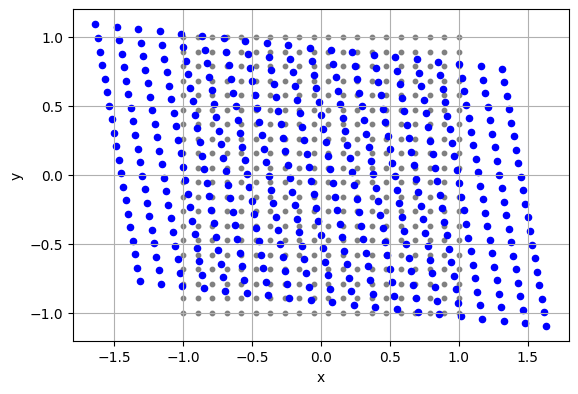

In [7]:
frc.plot_midplane_deformation_2d(epsilon_bar, magnification=50_000) 


Let us now plot the stress distribution of the stress component $\sigma_{xx}$ across the depth. Recall that each lamina is in a state of plane stress, and that the stress in lamina $k$ can be computed in terms of the miplane strains $\mathbf{\bar{\epsilon}}$ and curvatures $\mathbf{\bar{\kappa}}$ as
$$
\mathbf{\sigma}^{(k)} = \bar{Q}(\theta_k)(\mathbf{\bar{\epsilon}} - z\mathbf{\bar{\kappa}}).
$$
The function `plot_laminate_stress_z` plots a desired stress component as a function of the $z$-coordinate.  

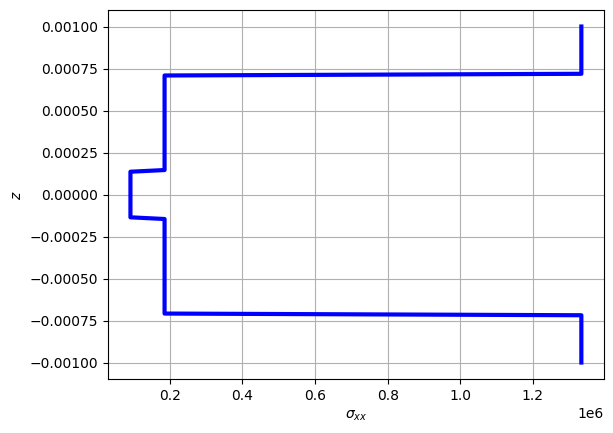

In [8]:
frc.plot_laminate_stress_z(laminate_1, epsilonbar=epsilon_bar, component='XX')

This tells us two things: (i) the stress distribution is discontinuous across the laminate depth, and (ii) the variation of stress within an individual ply over its thickness is negligible. The first point has important implication for failure in composites, and the second point implies that it is sufficient to calculate the stresses just at the midplane of each ply to understand the stress distribution.

*Exercise:* Plot the other components of the stress by modifying the `component` argument in the `plot_laminate_stress_z` function. 

### Example 2
Solve the same problem as problem 1, but with an asymmetric laminate with the following ply sequence $[0, 45, 45, 90, 45, 45, \theta]$, where $\theta$ can vary between $0$ and $90$ degrees.

**Solution:**
Since we are required to understand the behavior of the laminate as the orientation of the topmost ply varies over a range, it is useful to write a function that analyzes the laminate for a given orientation.

Note that since the laminate is not symmetric, we need to use the full $ABD$  matrix. Further, we need to specify both the stress resultant $\mathbf{N}$ and the moment resultant $\mathbf{M}$ as a single vector.

In [9]:
def analyze_laminate_ex2(theta_top_ply, plot=True, magnification=1, zlim=None):
    laminate_2 = frc.Laminate(
        theta=[0,45,45,90,45,45,theta_top_ply], 
        t=2e-3,
        E1=1.4e11,
        E2=1e10,
        nu12=0.3,
        G12=7e9
    )
    
    NM = np.array([
        1e3, 0.0, 0.0, # Components of N
        0.0, 0.0, 0.0 # Components of M
    ])
    midplane_strain = np.linalg.inv(laminate_2.ABD) @ NM
    epsilon_bar = midplane_strain[:3]
    kappa_bar = midplane_strain[3:]

    if plot:
        frc.plot_midplane_deformation_3d(epsilon_bar, kappa_bar, magnification=magnification, zlim=zlim)
    
    return epsilon_bar, kappa_bar

The code snippet shown below illustrates how the laminate deforms when the top ply has a 60 degrees orientation. 

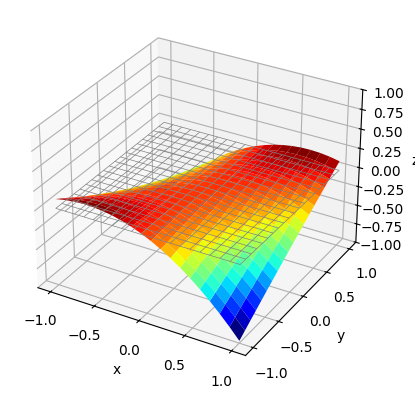

[ 2.41601429e-05 -2.05460801e-06 -1.72211903e-05]
[-0.0204307 -0.0008437  0.0136023]


In [10]:
epsilon_bar, kappa_bar = analyze_laminate_ex2(60, magnification=40, zlim=(-1.0, 1.0))
print(epsilon_bar)
print(kappa_bar)

The code snippet shows an interactive plot of how the deformation of the laminate changes by just changing the orientation of the top ply.

In [11]:
ipywidgets.interact(
    analyze_laminate_ex2, 
    theta_top_ply=(0.0, 90.0, 5.0),
    plot=ipywidgets.fixed(True), 
    magnification=ipywidgets.fixed(40), 
    zlim=ipywidgets.fixed((-1, 1))   
)

interactive(children=(FloatSlider(value=45.0, description='theta_top_ply', max=90.0, step=5.0), Output()), _do…

<function __main__.analyze_laminate_ex2(theta_top_ply, plot=True, magnification=1, zlim=None)>

### Example 3
This example provides an interactive simulation of how a laminate deforms when subject to different combination of running loads and moments. Modify the cell below to let `test_laminate` be any laminate of your choice and run the cell below that to understand how it deforms.

In [12]:
test_laminate = frc.Laminate(
    theta = [0, 90, 0, 90, 0, 90, 0, 90],
    t=2e-3,
    E1=1.81e11,
    E2=1.03e10,
    nu12=0.28,
    G12=7.17e9
)

In [13]:
@ipywidgets.interact(
    Nx=(-2.5e3, 2.5e3, 1e2),
    Ny=(-2.5e3, 2.5e3, 1e2),
    Nxy=(-2.5e3, 2.5e3, 1e2),
    Mx=(-1.0, 1.0, 0.1),
    My=(-1.0, 1.0, 0.1),
    Mxy=(-0.6, 0.6, 0.1)   
)
def visualize_laminate_deformation(
    Nx=0.0, Ny=0.0, Nxy=0.0,
    Mx=0.0, My=0.0, Mxy=0.0
):
    NM = np.array([
        Nx, Ny, Nxy, # Components of N
        Mx, My, Mxy # Components of M
    ])
    midplane_strain = np.linalg.inv(test_laminate.ABD) @ NM
    epsilon_bar = midplane_strain[:3]
    kappa_bar = midplane_strain[3:]
    frc.plot_midplane_deformation_3d(
        epsilon_bar, 
        kappa_bar, 
        magnification=20, 
        zlim=(-1.0, 1.0)
    )

interactive(children=(FloatSlider(value=0.0, description='Nx', max=2500.0, min=-2500.0, step=100.0), FloatSlid…